# Ejercicio 1. Rust

A continuación se presenta la implementacion en Rust de la simulación del entrenamiento de Naruto.

Cabe mencionar que se hace mediante un proyecto dado que la librería para generar numeros aleatorios es externa al crate standar.

Además, se utiliza un script de Python para ejecutar multiples veces el script de Rust y evaluar los resultados.

In [1]:
!mkdir src

In [2]:
%%writefile src/naruto_training.rs

use std::thread;
use rand::{self,Rng};

const MIN_CHAKRA:u32 = 5;
const MAX_CHAKRA:u32 = 10;
const MIN_DURATION_S:f32 = 0.1;
const MAX_DURATION_S:f32 = 0.2;
const SUCCESS_RATE:f32 = 0.5;

fn clone() -> u32 {
    let chakra = rand::rng().random_range(MIN_CHAKRA..=MAX_CHAKRA);
    let mut succeses = 0u32;

    for _ in 0..chakra{
        let duration = rand::rng().random_range(MIN_DURATION_S..=MAX_DURATION_S);
        thread::sleep(std::time::Duration::from_secs_f32(duration));
        if rand::random::<f32>() < SUCCESS_RATE {
            succeses += 1;
        }
    }
    succeses
}

fn thread_work(clones: u32) -> u32 {
    let mut successes = 0;
    for _ in 0..clones {
        successes += clone();
    }
    successes
}

fn get_enviorment() -> (usize, usize){
    let num_clones = std::env::var("NUM_CLONES")
    .expect("NUM_CLONES not set")
    .parse::<usize>()
    .expect("NUM_CLONES must be a positive integer");

    let num_threads = std::env::var("NUM_THREADS").
    expect("NUM_THREADS not set")
    .parse::<usize>()
    .expect("NUM_THREADS must be a positive integer");

    (num_clones, num_threads)
}


fn thread_master() -> u32{
    let (num_clones, num_threads) = get_enviorment();

    (0..num_clones).collect::<Vec<_>>()
    .chunks(num_threads)
    .into_iter()
    .map(|chunk|{
        let len = chunk.len();
        thread::spawn(move || thread_work(len as u32) )
    }).map(|thread| thread.join().unwrap())
    .reduce(|acc, sum| acc + sum)
    .unwrap()
}

fn main(){
    let time_0 = std::time::Instant::now();
    let level = thread_master();
    let time_1 = std::time::Instant::now();
    let elapsed = time_1.duration_since(time_0);
    println!("Level: {}", level);
    println!("Time elapsed in seconds: {:?}", elapsed.as_secs_f32());
}
/*
    Lo óptimo es que la cantidad de clones sea un múltiplo de la cantidad de hilos, para que cada hilo tenga la misma cantidad de clones.
    Si no es así, el último hilo tendrá menos clones que los demás y por tanto no se aprovechará completamente la capacidad de procesamiento.
    Como tanto el tiempo consumido como el nivel alcanzado son lineales respecto a la cantidad de clones, ninguna cantidad de clones es mejor que otra,
    salvo por lo comentado sobre la relación con la cantidad de hilos.

    Esto asumiendo que los hilos corresponde a computo realmente paralelo. En caso contrario, no habría una diferencia de eficiencia entre
    distintas cantidades de clones.
*/

Writing src/naruto_training.rs


In [3]:
%%writefile Cargo.toml

[package]
name = "naruto_training"
version = "0.1.0"
edition = "2021"

[dependencies]
rand = "0.9.1"

[[bin]]
name = "naruto_training"
path = "src/naruto_training.rs"


Writing Cargo.toml


In [27]:
%%writefile run_command.py

# /// script
# requires-python = ">=3.9"
# dependencies = [
#     "matplotlib",
#     "tqdm",
# ]
# ///

import subprocess
import sys

MIN_CLONES = 2
MAX_CLONES = 12
NUM_CALLS = 6
NUM_THREADS = 4
PLOT_FILE = "results.png"

def parse_output(output: str) -> tuple[int,float]:
    """
    Parses the output of the Rust program to extract the level reached and the time taken.
    """
    lines = list(output.splitlines())
    level = int(lines[0].split(": ")[1])
    seconds = float(lines[1].split(": ")[1])
    return level, seconds

def call_rust_program(num_clones: int) -> tuple[int, float]:
    """
    Calls the Rust program with the specified number of clones and returns the level reached and time taken.
    """
    rust_env = {
        "NUM_CLONES": str(num_clones),
        "NUM_THREADS": str(NUM_THREADS),
    }
    result = subprocess.run(
        ["./target/debug/naruto_training"],
        env=rust_env,
        input=None,
        capture_output=True,
        text=True
    )
    return parse_output(result.stdout.strip())

def generate_results() -> list[tuple[int, int, float]]:
    """
    Generates the results for the Rust program by calling it with different numbers of clones.
    """
    from tqdm import tqdm
    results = []
    progress_bar = tqdm(total=(MAX_CLONES - MIN_CLONES + 1) * NUM_CALLS, desc="Generating results", unit="call", file = sys.stdout)

    for num_clones in range(MIN_CLONES, MAX_CLONES + 1):
        for _ in range(NUM_CALLS):
            level, seconds = call_rust_program(num_clones)
            results.append((num_clones, level, seconds))
            progress_bar.update(1)
    return results

def plot_results(results: list[tuple[int, int, float]]):
    """
    Plots the results of the Rust program.
    """
    import matplotlib.pyplot as plt

    num_clones, levels, times = zip(*results)


    plt.scatter(num_clones, levels, label='Level Reached', color='blue')
    plt.scatter(num_clones, times, label='Time Taken (s)', color='red')


    plt.xlabel('Number of Clones')
    plt.ylabel('Level Reached / Time Taken (s)')
    plt.title('Rust Program Performance')
    plt.legend()

    plt.savefig(PLOT_FILE)
    print(f"Plot saved to {PLOT_FILE}")

def main():
    results = generate_results()
    plot_results(results)
    print("Results generated and plotted.")

if __name__ == "__main__":
    main()



Overwriting run_command.py


In [5]:
!sudo apt-get install cargo 1>/dev/null 2>/dev/null

In [6]:
!cargo build --bin naruto_training

    Updating crates.io index
  Downloaded ppv-lite86 v0.2.21
  Downloaded cfg-if v1.0.0
  Downloaded getrandom v0.3.3
  Downloaded rand_chacha v0.9.0
  Downloaded rand_core v0.9.3
  Downloaded rand v0.9.1
  Downloaded zerocopy v0.8.25
  Downloaded libc v0.2.172
   Compiling libc v0.2.172
   Compiling getrandom v0.3.3
   Compiling zerocopy v0.8.25
   Compiling cfg-if v1.0.0
   Compiling rand_core v0.9.3
   Compiling ppv-lite86 v0.2.21
   Compiling rand_chacha v0.9.0
   Compiling rand v0.9.1
   Compiling naruto_training v0.1.0 (/content)
    Finished dev [unoptimized + debuginfo] target(s) in 15.04s


Debemos modificar la variable de entorno MPLBACKEND para hacer esta ejecución compatible con Jupyter Notebook.

In [28]:
!MPLBACKEND=agg uv run run_command.py 2>/dev/null

Generating results: 100% 66/66 [08:38<00:00,  7.85s/call]
Plot saved to results.png
Results generated and plotted.


La forma más facíl de traer la imagen al Notebook y que reaccione a los cambios es usando una pequeña celda de Python en el propio notebook.

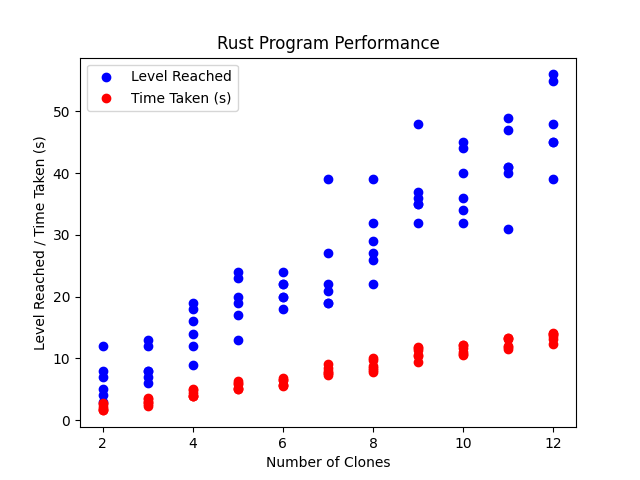

In [29]:
from IPython.display import Image
Image("results.png")

# Ejercicio 2. Python

**Código**

A continuación se presenta la implementación del programa en Python, cuyo objetivo es simular un torneo del Apertura 1992.

In [ ]:
%%writefile tourney_sim.py

import random
import time
import numpy as np
from concurrent.futures import ThreadPoolExecutor

TEAM_NAMES = [
  "Boca Juniors", "River Plate", "San Lorenzo", "Ferro", "Huracan", "Velez",
  "Estudiantes (LP)", "Belgrano", "Lanus", "Talleres (C)", "Dep Espaniol",
  "San Martin (T)", "Dep Mandiyu (C)", "Rosario Central", "Independiente",
  "Racing Club", "Gimnasia (LP)", "Platense", "Argentinos", "Newells"
]
POINTS_WIN = 2
POINTS_DRAW = 1
GOAL_LAMBDA = 1.0
SIM_SLEEP_MIN = 0.1
SIM_SLEEP_MAX = 0.15
MAX_WORKERS = 10


def generate_round_robin(teams):
  teams = list(teams)
  if len(teams) % 2:
    teams.append(None)
  rounds = []
  n = len(teams)
  for _ in range(n - 1):
    pairs = []
    for i in range(n // 2):
      home, away = teams[i], teams[-1 - i]
      if home and away:
        pairs.append((home, away))
    rounds.append(pairs)
    teams = [teams[0], teams[-1]] + teams[1:-1]
  return rounds


class StandingsTable:
  def __init__(self, teams):
    template = {
      'pts': 0, 'played': 0, 'wins': 0,
      'draws': 0, 'losses': 0,
      'gf': 0, 'ga': 0, 'gd': 0
    }
    self.stats = {team: template.copy() for team in teams}

  def update(self, home, away, hg, ag):
    self._record_match(home, away, hg, ag)
    self._assign_points(home, away, hg, ag)

  def _record_match(self, home, away, hg, ag):
    for team, goals_for, goals_against in ((home, hg, ag), (away, ag, hg)):
      s = self.stats[team]
      s['played'] += 1
      s['gf'] += goals_for
      s['ga'] += goals_against
      s['gd'] = s['gf'] - s['ga']

  def _assign_points(self, home, away, hg, ag):
    if hg > ag:
      self._win(home, away)
    elif hg < ag:
      self._win(away, home)
    else:
      self._draw(home, away)

  def _win(self, winner, loser):
    self.stats[winner]['wins'] += 1
    self.stats[loser]['losses'] += 1
    self.stats[winner]['pts'] += POINTS_WIN

  def _draw(self, team1, team2):
    for team in (team1, team2):
      self.stats[team]['draws'] += 1
      self.stats[team]['pts'] += POINTS_DRAW

  def get_rankings(self):
    return sorted(
      self.stats.items(),
      key=lambda x: (x[1]['pts'], x[1]['gd'], x[1]['gf']),
      reverse=True
    )


def simulate_match(match):
  home, away = match
  time.sleep(random.uniform(SIM_SLEEP_MIN, SIM_SLEEP_MAX))
  home_goals = np.random.poisson(GOAL_LAMBDA)
  away_goals = np.random.poisson(GOAL_LAMBDA)
  return home, away, int(home_goals), int(away_goals)


def run_sequential(rounds):
  table = StandingsTable(TEAM_NAMES)
  start = time.perf_counter()
  for round_matches in rounds:
    for match in round_matches:
      result = simulate_match(match)
      table.update(*result)
  duration = time.perf_counter() - start
  print("-- Sequential Simulation --")
  print_standings(table)
  print(f"Total time: {duration:.3f} seconds")


def run_concurrent(rounds, workers=None):
  table = StandingsTable(TEAM_NAMES)
  start = time.perf_counter()
  for round_matches in rounds:
    with ThreadPoolExecutor(max_workers=workers) as executor:
      futures = [executor.submit(simulate_match, m) for m in round_matches]
      for future in futures:
        table.update(*future.result())
  duration = time.perf_counter() - start
  print("-- Concurrent Simulation --")
  print_standings(table)
  print(f"Total time: {duration:.3f} seconds")


def print_standings(table):
  header = f"{'Equipo':<20} {'Pts':>4} {'PJ':>3} {'PG':>3} {'PE':>3} {'PP':>3} {'GF':>3} {'GC':>3} {'DIF':>4}"
  print(header)
  print("-" * len(header))
  for team, stats in table.get_rankings():
    print(f"{team:<20} {stats['pts']:>4} {stats['played']:>3} {stats['wins']:>3} {stats['draws']:>3} {stats['losses']:>3} {stats['gf']:>3} {stats['ga']:>3} {stats['gd']:>4}")
  print("-" * len(header))


if __name__ == '__main__':
  schedule = generate_round_robin(TEAM_NAMES)
  run_sequential(schedule)
  print()
  run_concurrent(schedule, workers=MAX_WORKERS)

Writing tourney_sim.py




---


**Ejecución**

A continuación se ejecuta el programa, mostrando los resultados de la simulación concurrente y la secuencial con sus respectivos tiempos de ejecución.

**Nota**: tardará entre 20 y 30 segundos en completarse.

In [ ]:
!python3 tourney_sim.py

-- Sequential Simulation --
Equipo                Pts  PJ  PG  PE  PP  GF  GC  DIF
------------------------------------------------------
Newells                24  19   8   8   3  19  11    8
Huracan                24  19  10   4   5  24  17    7
River Plate            22  19  10   2   7  21  16    5
Velez                  22  19  10   2   7  22  18    4
San Martin (T)         21  19   6   9   4  18  11    7
Platense               21  19   9   3   7  17  16    1
Racing Club            20  19   6   8   5  11  10    1
Boca Juniors           19  19   7   5   7  23  20    3
Argentinos             19  19   5   9   5  16  16    0
San Lorenzo            19  19   7   5   7  13  14   -1
Rosario Central        19  19   6   7   6  12  13   -1
Lanus                  19  19   6   7   6  23  26   -3
Estudiantes (LP)       19  19   4  11   4  21  24   -3
Dep Mandiyu (C)        18  19   6   6   7  15  16   -1
Gimnasia (LP)          18  19   7   4   8  13  16   -3
Dep Espaniol           17  19   6   5



---

Habiendo tomado 10 tiempos de ejecución en Colab, los promedios obtenidos fueron:

**Simulación Secuencial**: 23,824 segundos

**Simulación Concurrente**: 2,795 segundos

# Ejercicio 3. Go




**Preparación del entorno**

In [ ]:
!sudo apt update
!sudo apt install -y golang-go

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,721 kB]
Hit:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,212 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,930 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Pac

Verificación de la instalación

In [ ]:
!go version

go version go1.18.1 linux/amd64




---


**Código**


Creación de los archivos necesarios, el programa y el archivo visualizaciones.csv

In [ ]:
%%writefile preferences.go
package main

import (
	"encoding/csv"
	"encoding/json"
	"fmt"
	"os"
	"path/filepath"
	"runtime"
	"sync"
)

const (
	PreferencesFileName = "visualizaciones.csv"
	UserIdColumn        = 0
	UserNameColumn      = 1
	TitleColumn         = 2
	TypeColumn          = 3
	GenreColumn         = 4
	CurrentGoRoutine    = 1
	Error               = 1
	CurrentExecution    = 0
	SkipHeader          = 1
	Currentuser         = 0
)

type Visualization struct {
	UserID   string
	UserName string
	Title    string
	Type     string
	Genre    string
}

type Preference struct {
	UserID          string `json:"user_id"`
	UserName        string `json:"user_name"`
	ChosenGenre     string `json:"chosen_genre"`
	ChosenType      string `json:"chosen_type"`
	Total           int    `json:"total"`
	DifferentGenres int    `json:"different_genres"`
}

func getRootDir() string {
	_, callerFile, _, ok := runtime.Caller(CurrentExecution)
	if !ok {
		fmt.Println("Could not get callerFile")
		os.Exit(Error)
	}
	return filepath.Dir(callerFile)
}

func getVisualizationsMap(records [][]string) map[string][]Visualization {
	visualizations := make(map[string][]Visualization)

	for _, record := range records[SkipHeader:] {
		userId := record[UserIdColumn]
		vis := Visualization{
			UserID:   userId,
			UserName: record[UserNameColumn],
			Title:    record[TitleColumn],
			Type:     record[TypeColumn],
			Genre:    record[GenreColumn],
		}
		visualizations[userId] = append(visualizations[userId], vis)
	}

	return visualizations
}

func readVisualizationsFile(file *os.File) ([][]string, error) {
	reader := csv.NewReader(file)
	records, err := reader.ReadAll()
	return records, err
}

func getVisualizations(filePath string) map[string][]Visualization {
	f, err := os.Open(filePath)
	if err != nil {
		fmt.Println("Could not open file visualizaciones.csv", err)
		return nil
	}
	defer f.Close()
	records, err := readVisualizationsFile(f)

	if err != nil {
		fmt.Println("Error reading CSV:", err)
		return nil
	}

	visualizations := getVisualizationsMap(records)
	return visualizations
}

func getPreferred(field map[string]int) string {
	var maxKeyCount int
	var chosenFieldValue string

	for key, count := range field {
		if count > maxKeyCount {
			maxKeyCount = count
			chosenFieldValue = key
		}
	}

	return chosenFieldValue
}

func getPreference(userId string, userName string, chosenGenre string, chosenType string, totalVisualizations int, genreCount map[string]int) Preference {
	preference := Preference{
		UserID:          userId,
		UserName:        userName,
		ChosenGenre:     chosenGenre,
		ChosenType:      chosenType,
		Total:           totalVisualizations,
		DifferentGenres: len(genreCount),
	}
	return preference
}

func createPreferences(userId string, userName string, visualizations []Visualization, wg *sync.WaitGroup) {
	defer wg.Done()

	genreCount := make(map[string]int)
	typeCount := make(map[string]int)

	for _, visualization := range visualizations {
		genreCount[visualization.Genre]++
		typeCount[visualization.Type]++
	}

	chosenGenre := getPreferred(genreCount)
	chosenType := getPreferred(typeCount)
	preference := getPreference(userId, userName, chosenGenre, chosenType, len(visualizations), genreCount)

	writePreferenceToFile(userId, preference)
}

func createOutputFilePath(userId string) (string, *os.File, error) {
	root := getRootDir()
	outFileName := fmt.Sprintf("user_%s_preferences.csv", userId)
	outFilePath := filepath.Join(root, outFileName)
	outputFile, err := os.Create(outFilePath)
	return outFileName, outputFile, err
}

func writePreferenceToFile(userId string, preference Preference) {
	outFileName, outputFile, err := createOutputFilePath(userId)
	if err != nil {
		fmt.Printf("Error creating preferences file for user %s: %v", userId, err)
		return
	}

	defer outputFile.Close()

	encoder := json.NewEncoder(outputFile)
	encoder.SetIndent("", "  ")
	if err := encoder.Encode(preference); err != nil {
		fmt.Printf("Error writing preferences to file for user %s: %v", userId, err)
		return
	}
	fmt.Printf("Preferences for user %s written to %s\n", userId, outFileName)
}

func mergePreferencesFiles(visualizations map[string][]Visualization, root string) {
	mergedFilePath := filepath.Join(root, "preferencias.json")
	mergedFile, err := os.Create(mergedFilePath)
	if err != nil {
		fmt.Printf("Error creating merged preferences file: %v", err)
		return
	}
	defer mergedFile.Close()

	allPreferences := loadUsersPreferences(visualizations, root)

	encoder := json.NewEncoder(mergedFile)
	encoder.SetIndent("", "  ")
	if err := encoder.Encode(allPreferences); err != nil {
		fmt.Printf("Error writing merged preferences: %v\n", err)
		return
	}

	fmt.Printf("Merged preferences written to %s\n", mergedFilePath)
}

func loadUsersPreferences(visualizations map[string][]Visualization, root string) []Preference {
	var allPreferences []Preference

	for userId := range visualizations {
		preference, err := loadUserPreference(userId, root)
		if err != nil {
			fmt.Printf("Error processing user %s: %v\n", userId, err)
			continue
		}
		allPreferences = append(allPreferences, preference)
		fmt.Printf("Loaded preferences for user %s\n", userId)
	}

	return allPreferences
}

func loadUserPreference(userId string, root string) (Preference, error) {
	var preference Preference
	userFileName, userFilePath, file, err := createUserFilePath(userId, root)

	if err != nil {
		return preference, fmt.Errorf("opening file %s: %w", userFileName, err)
	}

	if err := json.NewDecoder(file).Decode(&preference); err != nil {
		file.Close()
		return preference, fmt.Errorf("decoding file %s: %w", userFileName, err)
	}
	file.Close()

	if err := os.Remove(userFilePath); err != nil {
		fmt.Printf("Warning: failed to delete file %s: %v\n", userFileName, err)
	}
	return preference, nil
}

func createUserFilePath(userId string, root string) (string, string, *os.File, error) {
	userFileName := fmt.Sprintf("user_%s_preferences.csv", userId)
	userFilePath := filepath.Join(root, userFileName)
	file, err := os.Open(userFilePath)
	return userFileName, userFilePath, file, err
}

func main() {

	root := getRootDir()
	filePath := filepath.Join(root, PreferencesFileName)

	visualizations := getVisualizations(filePath)

	var wg sync.WaitGroup

	for userId, visualizations := range visualizations {
		wg.Add(CurrentGoRoutine)
		go createPreferences(userId, visualizations[Currentuser].UserName, visualizations, &wg)
	}

	wg.Wait()

	mergePreferencesFiles(visualizations, root)

}


Writing preferences.go


In [ ]:
%%writefile visualizaciones.csv
user_id,user_name,title,type,genre
5,p_kiki,Hereditary,Película,Terror
2,daro123,La Casa de Papel,Serie,Drama
1,p_kiki,The Office,Serie,Comedia
3,luna99,Get Out,Película,Terror
4,max_power,Stranger Things,Serie,Ciencia Ficción
1,p_kiki,Friends,Serie,Comedia
2,daro123,Inception,Película,Ciencia Ficción
5,p_kiki,The Conjuring,Película,Terror
3,luna99,The Crown,Serie,Drama
4,max_power,The Matrix,Película,Ciencia Ficción
2,daro123,Breaking Bad,Serie,Drama
1,p_kiki,Brooklyn Nine-Nine,Serie,Comedia
3,luna99,Black Mirror,Serie,Ciencia Ficción
5,p_kiki,It,Película,Terror
4,max_power,Dark,Serie,Ciencia Ficción

Writing visualizaciones.csv




---


**Ejecución**

A continuación se ejecuta el programa preferences.go, que genera el archivo preferencias.json

In [ ]:
!go run preferences.go

Preferences for user 5 written to user_5_preferences.csv
Preferences for user 3 written to user_3_preferences.csv
Preferences for user 4 written to user_4_preferences.csv
Preferences for user 1 written to user_1_preferences.csv
Preferences for user 2 written to user_2_preferences.csv
Loaded preferences for user 5
Loaded preferences for user 2
Loaded preferences for user 1
Loaded preferences for user 3
Loaded preferences for user 4
Merged preferences written to /content/preferencias.json




---

**Visualización**

Finalmente, se muestra el contenido del archivo de preferencias generado.

In [ ]:
!cat preferencias.json

[
  {
    "user_id": "5",
    "user_name": "p_kiki",
    "chosen_genre": "Terror",
    "chosen_type": "Película",
    "total": 3,
    "different_genres": 1
  },
  {
    "user_id": "2",
    "user_name": "daro123",
    "chosen_genre": "Drama",
    "chosen_type": "Serie",
    "total": 3,
    "different_genres": 2
  },
  {
    "user_id": "1",
    "user_name": "p_kiki",
    "chosen_genre": "Comedia",
    "chosen_type": "Serie",
    "total": 3,
    "different_genres": 1
  },
  {
    "user_id": "3",
    "user_name": "luna99",
    "chosen_genre": "Terror",
    "chosen_type": "Serie",
    "total": 3,
    "different_genres": 3
  },
  {
    "user_id": "4",
    "user_name": "max_power",
    "chosen_genre": "Ciencia Ficción",
    "chosen_type": "Serie",
    "total": 3,
    "different_genres": 1
  }
]
